# Validation of first, internal classification
Felix Zaussinger | XX.YY.ZZZZ

## Core Analysis Goal(s)
1.
2.
3.

## Key Insight(s)
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils

# import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("talk")
sns.set(rc={"figure.figsize": (6, 3.0)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

#### Import validated GBN classification file (V1 - Internal)

There are several versions:

Green
- narrow: esco_ess > 0 & (onet_vona | onet_gtp | onet_jrc) > 0
- wide: esco > 0 & (onet_vona | onet_gtp | onet_jrc) > 0

Brown
- narrow: esco_ess > 0 & onet_vona > 0
- wide: esco > 0 & onet_vona > 0
- widest: esco > 0 | onet_vona > 0

Question:
When sorting occupations by ESCO green/brown shares and showing their manual classification status, is there an apparent cutoff in the distribution?

In [2]:
fpath_validated_gbn_classification = r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\2022-06-03_Occupation_Classification_Review_INTERNAL.xlsx"

dfs = pd.read_excel(fpath_validated_gbn_classification, sheet_name=None)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Code ...

In [3]:
dfs.keys()

dict_keys(['summary', 'green_narrow', 'green_wide', 'brown_narrow', 'brown_wide', 'brown_widest', 'validation_choices', 'green_short_list', 'brown_short_list'])

Plot
- x-axis: occupations sorted by green/brown shares in 10% bins
- y-axis: manual classification (TRUE/FALSE)

In [4]:
dfs["brown_widest"]

,id,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,gbn_classification_esco,gbn_classification_esco_ess,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,is_brown_eth,classification_felix,is_brown_felix2
0,1318,http://data.europa.eu/esco/occupation/5e748def...,marine fitter,"Marine fitters work primarily in fabrication, ...",7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.153846,0.130435,0.222222,False,NaN,NaN
1,1324,http://data.europa.eu/esco/occupation/f49d893a...,forestry machinery technician,Forestry machinery technicians maintain and tr...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.107143,0.157895,0.222222,False,NaN,NaN
2,1316,http://data.europa.eu/esco/occupation/599c2ce9...,forge equipment technician,Forge equipment technicians maintain and repai...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,neutral,neutral,0.078947,0.142857,0.222222,False,NaN,NaN
3,1005,http://data.europa.eu/esco/occupation/8d3fd879...,precast moulder,Precast moulders handcast decorative and struc...,8114,811,81,8,"Cement, stone and other mineral products machi...",Mining and mineral processing plant operators,Stationary plant and machine operators,Plant and machine operators and assemblers,brown,brown,0.550000,0.600000,0.250000,True,NaN,NaN
4,947,http://data.europa.eu/esco/occupation/ee37a4a5...,tracer powder blender,Tracer powder blenders operate machines and eq...,8131,813,81,8,Chemical products plant and machine operators,Chemical and photographic products plant and m...,Stationary plant and machine operators,Plant and machine operators and assemblers,brown,brown,0.538462,0.571429,0.666667,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,1305,http://data.europa.eu/esco/occupation/ac160654...,woodturner,Woodturners use a lathe to remove superfluous ...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.071429,0.117647,1.000000,False,NaN,NaN
913,1302,http://data.europa.eu/esco/occupation/77a05858...,wooden furniture machine operator,Wooden furniture machine operators run machine...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.057143,0.000000,1.000000,False,NaN,NaN
914,1304,http://data.europa.eu/esco/occupation/a77bc925...,wood pallet maker,Wood pallet makers create wood pallets for use...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.052632,0.000000,1.000000,False,NaN,NaN
915,1303,http://data.europa.eu/esco/occupation/7e08d38d...,wood boring machine operator,Wood boring machine operators use milling mach...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,neutral,neutral,0.048780,0.000000,1.000000,False,NaN,NaN


#### Visualise effect of manual classification (TRUE/False/?)
1) across sorted occupations (histplot)
2) across share scores (boxplot)

Brown widest

With stat="percent", all bars sum up to 100. To have the bars belonging to the same x-value summing up to 100, you can use multiple='fill'. Note that in the latter case, the sum is 1.0. The PercentFormatter shows the y-axis as percentages.

Source:
https://stackoverflow.com/questions/70234584/seaborn-how-to-scale-y-axis-to-100-percent-for-each-categorical-value

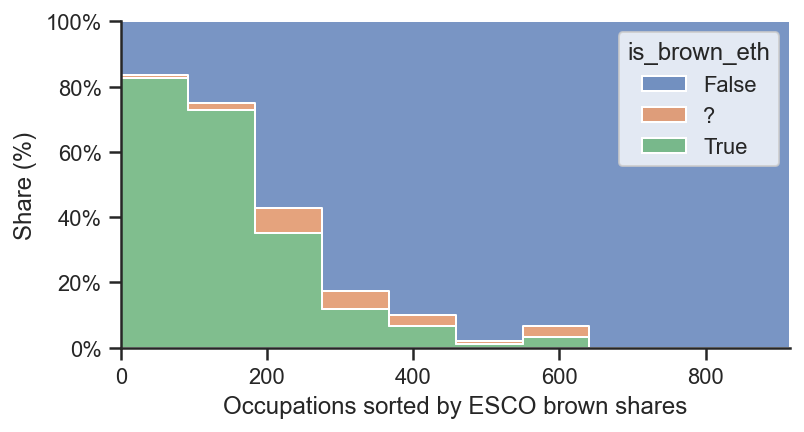

In [5]:
from matplotlib.ticker import PercentFormatter

ds = "brown_widest"
df = dfs[ds].sort_values("share_brown_esco", ascending=False).reset_index()

ax = sns.histplot(
    x=df.index,
    bins=10,
    hue=df.loc[:, "is_brown_eth"],
    hue_order=[False, "?", True],
    element="step",
    stat="percent",
    legend=True,
    multiple="fill",
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Share (%)")
ax.set_xlabel("Occupations sorted by ESCO brown shares")
sns.despine()

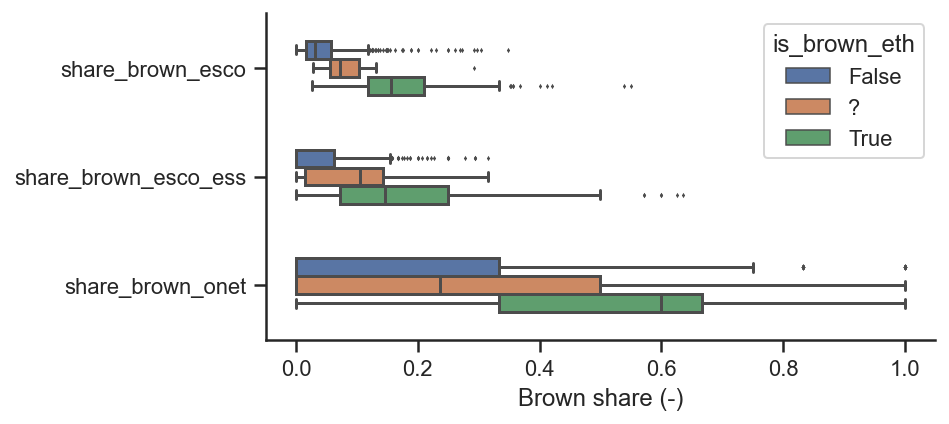

In [6]:
df_long = (
    utils.extract_cols_by_kw(df, "brown")
    .drop(columns=["is_brown_felix2"])
    .rename(columns={"share_brown_vona2018": "share_brown_onet"})
    .melt(id_vars="is_brown_eth")
)

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_brown_eth",
    hue_order=[False, "?", True],
    orient="h",
    width=0.5,
    fliersize=0.5,
)

ax.set_xlabel("Brown share (-)")
ax.set_ylabel(None)
sns.despine()

Green wide

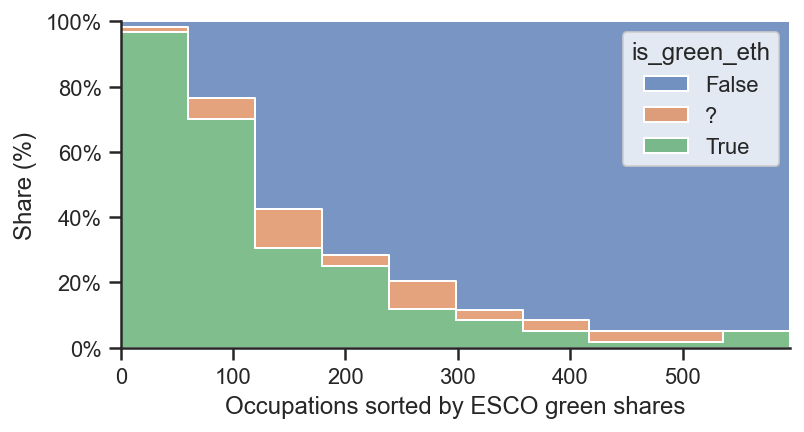

In [7]:
ds = "green_wide"
df = dfs[ds].sort_values("share_green_esco", ascending=False).reset_index()

ax = sns.histplot(
    x=df.index,
    bins=10,
    hue=df.loc[:, "is_green_eth"],
    hue_order=[False, "?", True],
    element="step",
    stat="percent",
    multiple="fill",
    legend=True,
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Share (%)")
ax.set_xlabel("Occupations sorted by ESCO green shares")
sns.despine()

In [8]:
(dfs["green_wide"].is_green_eth == True).sum() + (
    dfs["green_wide"].is_green_eth == "?"
).sum()

180

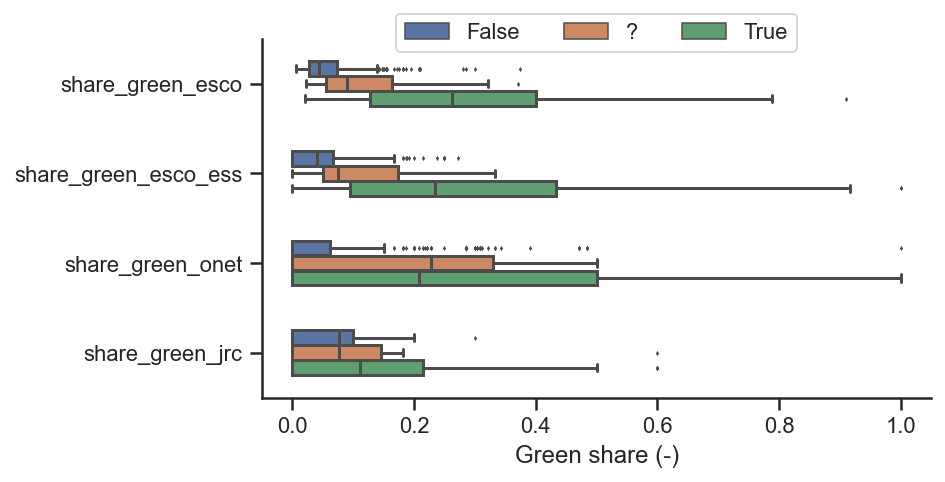

In [9]:
df_long = (
    utils.extract_cols_by_kw(df, "green")
    .drop(columns=["share_green_vona2018"])
    .rename(columns={"share_green_gtp": "share_green_onet"})
    .melt(id_vars="is_green_eth")
)

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_green_eth",
    hue_order=[False, "?", True],
    orient="h",
    width=0.5,
    fliersize=0.5,
)

ax.set_xlabel("Green share (-)")
ax.set_ylabel(None)
plotting_utils.move_legend_to_top(ax, ncol=3, scale=1.1)
sns.despine()

#### Create new occupation metadata files and aggregate to ISCO level

Read occupation metadata with occ hierarchy information and subset validated GBN classifications

In [10]:
occ_data = pd.read_pickle(
    r"T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\data\processed\esco\esco_occupation_hierarchy.pkl"
)

In [11]:
from src.data.framework import Esco

esco = Esco()

occ_data = esco.attach_isco_to_occupations(occupations=occ_data)
occ_data = occ_data.loc[:, ~occ_data.columns.duplicated()].copy()
occ_data

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_lvl_1,isco_lvl_2,isco_lvl_3,isco_lvl_4,esco_lvl_5,esco_lvl_6,esco_lvl_7,esco_lvl_8,is_esco_lvl_5,is_esco_lvl_6,is_esco_lvl_7,is_esco_lvl_8,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers"
1,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers"
2,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers"
3,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers"
4,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2,26,265,2654,2654.1,2654.1.4,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5947,Occupation,http://data.europa.eu/esco/occupation/b059d331...,9520,hawker,street trader\nmarket stall trader\ncar-boot s...,NaN,released,2021-10-06T08:30:39.429Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Hawkers sell goods and services on established...,9520.1,9,95,952,9520,9520.1,NaN,NaN,NaN,True,False,False,False,9520,9,95,952,Elementary occupations,Street and related sales and service workers,Street vendors (excluding food),Street vendors (excluding food)
5948,Occupation,http://data.europa.eu/es

In [12]:
green_validated = dfs["green_wide"].query("is_green_eth == True")
brown_validated = dfs["brown_widest"].query("is_brown_eth == True")

merge_key_col = "preferredLabel"
cols_green = [
    merge_key_col,
    "share_green_esco",
    "share_green_esco_ess",
    "share_green_gtp",
    "share_green_vona2018",
    "share_green_jrc",
]
cols_brown = [
    merge_key_col,
    "share_brown_esco",
    "share_brown_esco_ess",
    "share_brown_vona2018",
]

Merge

In [13]:
occ_data_merged = pd.merge(
    occ_data, green_validated[cols_green], how="left", on=merge_key_col
)
occ_data_merged = pd.merge(
    occ_data_merged, brown_validated[cols_brown], how="left", on=merge_key_col
)

occ_data_merged

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_lvl_1,isco_lvl_2,isco_lvl_3,isco_lvl_4,esco_lvl_5,esco_lvl_6,esco_lvl_7,esco_lvl_8,is_esco_lvl_5,is_esco_lvl_6,is_esco_lvl_7,is_esco_lvl_8,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2,26,265,2654,2654.1,2654.1.4,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5947,Occupation,http://data.europa.eu/esco/occupation/b059d331...,9520,hawker,street trader\nmarket stall trader\ncar-boot s...,NaN,released,2021-10-06T08:30:39.429Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://

Fill missing values in share columns with zero's

In [14]:
cols_to_fill = utils.extract_cols_by_kw(occ_data_merged, "share").columns.tolist()
occ_data_merged[cols_to_fill] = occ_data_merged[cols_to_fill].fillna(value=0)

In [15]:
occ_data_merged

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_lvl_1,isco_lvl_2,isco_lvl_3,isco_lvl_4,esco_lvl_5,esco_lvl_6,esco_lvl_7,esco_lvl_8,is_esco_lvl_5,is_esco_lvl_6,is_esco_lvl_7,is_esco_lvl_8,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2,26,265,2654,2654.1,2654.1.7,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2,26,265,2654,2654.1,2654.1.8,NaN,NaN,False,True,False,False,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2,26,265,2654,2654.1,2654.1.4,NaN,NaN,False,True,False,False,2654,2,26,265,Non-commissioned armed forces officers,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5947,Occupation,http://data.europa.eu/esco/occupation/b059d331...,9520,hawker,street trader\nmarket stall trader\ncar-boot s...,NaN,released,2021-10-06T08:30:39.429Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://

In [16]:
occ_data_merged_isco3 = occ_data_merged.groupby("isco_label_3").aggregate(np.mean)
occ_data_merged_isco3 = utils.extract_cols_by_kw(
    occ_data_merged_isco3, char_seq="share"
)

In [17]:
occ_data_merged_isco3.sort_values("share_green_esco", ascending=False)

,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
isco_label_3,,,,,,,,
Forestry and related workers,0.578947,0.687500,0.000000,0.000000,0.226667,0.000000,0.000000,0.0
Refuse workers,0.434615,0.370726,0.750000,0.750000,0.450000,0.000000,0.000000,0.0
Life science professionals,0.184109,0.199201,0.050000,0.072222,0.089167,0.000000,0.000000,0.0
Process control technicians,0.112168,0.088255,0.110714,0.053571,0.061924,0.040427,0.029844,0.2
"Production managers in agriculture, forestry and fisheries",0.097561,0.166667,0.000000,0.000000,0.022727,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...
Legal professionals,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
Keyboard operators,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
Information and communications technology service managers,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [18]:
occ_data_merged_isco3.sort_values("share_brown_esco", ascending=False)

,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
isco_label_3,,,,,,,,
Chemical and photographic products plant and machine operators,0.000000,0.000000,0.000000,0.000000,0.0,0.171180,0.216995,0.516129
Mining and mineral processing plant operators,0.000000,0.000000,0.000000,0.000000,0.0,0.168428,0.198029,0.567308
Metal processing and finishing plant operators,0.000000,0.000000,0.000000,0.000000,0.0,0.152624,0.086607,0.645614
"Rubber, plastic and paper products machine operators",0.000000,0.000000,0.000000,0.000000,0.0,0.113478,0.133332,0.349548
"Blacksmiths, toolmakers and related trades workers",0.000000,0.000000,0.000000,0.000000,0.0,0.098100,0.053169,0.228261
...,...,...,...,...,...,...,...,...
Information and communications technology service managers,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Information and communications technology operations and user support technicians,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
Hotel and restaurant managers,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [19]:
occ_data_merged.query("isco_label_3 == 'Forestry and related workers'")

,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_lvl_1,isco_lvl_2,isco_lvl_3,isco_lvl_4,esco_lvl_5,esco_lvl_6,esco_lvl_7,esco_lvl_8,is_esco_lvl_5,is_esco_lvl_6,is_esco_lvl_7,is_esco_lvl_8,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
5787,Occupation,http://data.europa.eu/esco/occupation/f489b1ec...,6210,forest ranger,woodland ranger\nforestry officer\nwoodland of...,NaN,released,2021-01-21T11:56:06.922Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Forest rangers are responsible for the protect...,6210.1,6,62,621,6210,6210.1,NaN,NaN,NaN,True,False,False,False,6210,6,62,621,"Skilled agricultural, forestry and fishery wor...","Market-oriented skilled forestry, fishery and ...",Forestry and related workers,Forestry and related workers,0.578947,0.6875,0.0,0.0,0.226667,0.0,0.0,0.0


# IF TOBI STILL VALIDATES: RE-START ANALYSIS HERE
Note 10.6.22

#### Final validated GBN classification file (V2 - REVIEWED by JRC and D. Consoli)
- Lower bound --> manual classification (validated short list)
- Upper bound --> threshold-based classification (long list)

In [20]:
fpath_manual_classification = r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\2022-06-03_Occupation_Classification_Review_MERGED_V6_short.xlsx"
dfs_manual_clsf = pd.read_excel(fpath_manual_classification, sheet_name=None, header=1)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


#### Green classification

The "lower bound green classification" results in 63 core green occupations. All raters need to rate them as TRUE. This is a very stringent selection !

In [21]:
dfs_manual_clsf["green_short_list"].is_green_final.sum()

91

In [22]:
dfs_manual_clsf["green_short_list"]

,preferredLabel,description,isco_label_4,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_jrc,is_green_eth,is_green_jrc,is_green_consoli,is_green_tobi,is_green_flo,is_green_final,comment_tobi,comment_flo
0,agricultural engineer,Agricultural engineers intervene in a variety ...,Mechanical engineers,0.279070,0.071429,0.285714,0.000000,True,True,False,False,NaN,False,too generic,NaN
1,agricultural scientist,Agricultural scientists research and study soi...,"Farming, forestry and fisheries advisers",0.281690,0.215686,0.000000,0.090909,True,True,False,False,NaN,False,not really convinced - depends on industry,NaN
2,agricultural technician,Agricultural technicians collect and conduct e...,Agricultural technicians,0.166667,0.100000,0.115385,0.000000,True,True,False,False,NaN,False,"too generic, depends on sector",NaN
3,agronomist,Agronomists provide consulting services to com...,"Farming, forestry and fisheries advisers",0.276316,0.312500,0.000000,0.090909,True,True,False,False,NaN,False,"not really relevant for our sectors. Also, dep...",NaN
4,air pollution analyst,Air pollution analysts conduct field and lab t...,Chemical and physical science technicians,0.423077,0.529412,1.000000,0.400000,True,True,True,True,NaN,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,water network operative,Water network operatives maintain pipes and pu...,Plumbers and pipe fitters,0.194444,0.076923,0.150000,0.000000,True,True,False,True,1.0,True,NaN,NaN
176,water plant technician,Water plant technicians maintain and repair wa...,Incinerator and water treatment plant operators,0.323529,0.333333,0.000000,0.076923,True,True,False,True,1.0,True,NaN,NaN
177,water quality analyst,Water quality analysts safeguard the quality o...,Environmental protection professionals,0.487805,0.153846,1.000000,0.000000,True,True,True,True,NaN,True,NaN,NaN
178,waterway construction labourer,Waterway maintenance labourers maintain canals...,Civil engineering labourers,0.127660,0.086957,0.000000,0.000000,True,True,False,False,NaN,False,not convinced. Derialing rivers is not necessa...,NaN


**Comparison within short list:**
- looks well separated!

In [23]:
res = dfs_manual_clsf["green_short_list"].groupby("is_green_final").mean()
utils.extract_cols_by_kw(res, "share")

,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_jrc
is_green_final,,,,
False,0.160105,0.146171,0.250794,0.093086
True,0.368414,0.368135,0.438916,0.175283


In [24]:
dfs_manual_clsf["green_short_list"]

,preferredLabel,description,isco_label_4,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_jrc,is_green_eth,is_green_jrc,is_green_consoli,is_green_tobi,is_green_flo,is_green_final,comment_tobi,comment_flo
0,agricultural engineer,Agricultural engineers intervene in a variety ...,Mechanical engineers,0.279070,0.071429,0.285714,0.000000,True,True,False,False,NaN,False,too generic,NaN
1,agricultural scientist,Agricultural scientists research and study soi...,"Farming, forestry and fisheries advisers",0.281690,0.215686,0.000000,0.090909,True,True,False,False,NaN,False,not really convinced - depends on industry,NaN
2,agricultural technician,Agricultural technicians collect and conduct e...,Agricultural technicians,0.166667,0.100000,0.115385,0.000000,True,True,False,False,NaN,False,"too generic, depends on sector",NaN
3,agronomist,Agronomists provide consulting services to com...,"Farming, forestry and fisheries advisers",0.276316,0.312500,0.000000,0.090909,True,True,False,False,NaN,False,"not really relevant for our sectors. Also, dep...",NaN
4,air pollution analyst,Air pollution analysts conduct field and lab t...,Chemical and physical science technicians,0.423077,0.529412,1.000000,0.400000,True,True,True,True,NaN,True,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,water network operative,Water network operatives maintain pipes and pu...,Plumbers and pipe fitters,0.194444,0.076923,0.150000,0.000000,True,True,False,True,1.0,True,NaN,NaN
176,water plant technician,Water plant technicians maintain and repair wa...,Incinerator and water treatment plant operators,0.323529,0.333333,0.000000,0.076923,True,True,False,True,1.0,True,NaN,NaN
177,water quality analyst,Water quality analysts safeguard the quality o...,Environmental protection professionals,0.487805,0.153846,1.000000,0.000000,True,True,True,True,NaN,True,NaN,NaN
178,waterway construction labourer,Waterway maintenance labourers maintain canals...,Civil engineering labourers,0.127660,0.086957,0.000000,0.000000,True,True,False,False,NaN,False,not convinced. Derialing rivers is not necessa...,NaN


In [25]:
from statsmodels.stats import inter_rater as irr

ratings = (
    dfs_manual_clsf["green_short_list"]
    .loc[:, ("is_green_eth", "is_green_jrc", "is_green_consoli")]
    .to_numpy()
)
dats, cats = irr.aggregate_raters(ratings)
irr.fleiss_kappa(dats, method="fleiss")

0.21875993640699515

**Comparison within long list (manual vs automatic classification)**
- again, looks well separated!

In [26]:
set_diff_right = utils.get_set_diff(
    dfs_manual_clsf["green_short_list"], dfs["green_wide"], "preferredLabel"
)

green_long_vs_short_list = pd.merge(
    dfs["green_wide"],
    dfs_manual_clsf["green_short_list"][set_diff_right],
    how="left",
    on="preferredLabel",
)
green_long_vs_short_list.is_green_final = (
    green_long_vs_short_list.is_green_final.fillna(False)
)

In [27]:
res = green_long_vs_short_list.groupby("is_green_final").mean()
utils.extract_cols_by_kw(res, "share")

,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc
is_green_final,,,,,
False,0.076762,0.063748,0.095683,0.111495,0.070757
True,0.368414,0.368135,0.438916,0.406538,0.175283


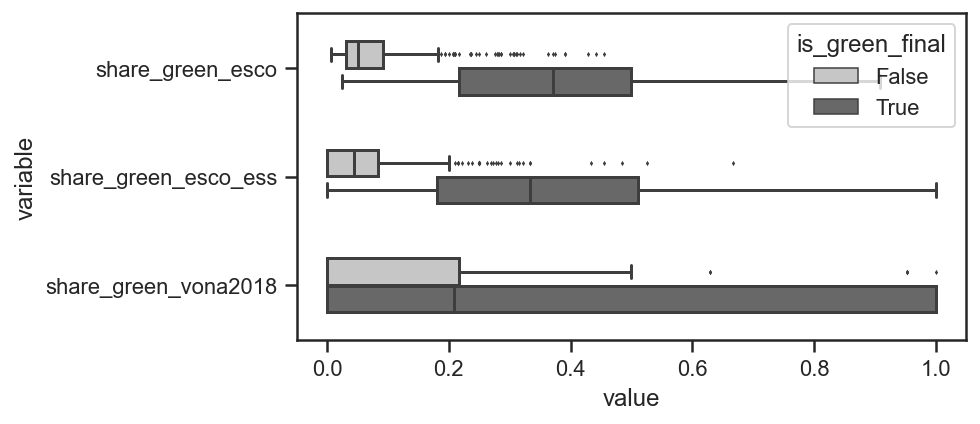

In [28]:
cols = [
    "is_green_final",
    "share_green_esco",
    "share_green_esco_ess",
    "share_green_vona2018",
]

df_long = green_long_vs_short_list[cols].melt(id_vars="is_green_final")

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_green_final",
    orient="h",
    width=0.5,
    fliersize=0.5,
    palette="Greys",
)

#### Brown classification

In [29]:
dfs_manual_clsf["brown_short_list"].is_brown_final.sum()

207

In [30]:
dfs_manual_clsf["brown_short_list"]

,preferredLabel,description,isco_label_4,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,is_brown_eth,is_brown_jrc,is_brown_consoli,is_brown_final
0,abrasive blasting operator,Abrasive blasting operators use the proper equ...,"Metal finishing, plating and coating machine o...",0.150000,0.222222,0.666667,True,True,True,True
1,air separation plant operator,Air separation plant operators control and mai...,Chemical processing plant controllers,0.105263,0.125000,1.000000,False,False,False,False
2,anodising machine operator,Anodising machine operators set up and tend an...,"Metal finishing, plating and coating machine o...",0.116279,0.071429,0.666667,True,True,True,True
3,asphalt plant operator,Asphalt plant operators extract raw materials ...,"Cement, stone and other mineral products machi...",0.184211,0.333333,0.250000,True,True,True,True
4,assayer,Assayers test and analyse precious metals such...,"Mining engineers, metallurgists and related pr...",0.142857,0.176471,0.600000,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...
213,well-digger,Well-diggers operate drilling machinery and eq...,Well drillers and borers and related workers,0.269231,0.300000,1.000000,True,True,True,True
214,wire weaving machine operator,Wire weaving machine operators set up and tend...,Metal processing plant operators,0.135135,0.062500,0.800000,True,True,True,True
215,wood drying kiln operator,Wood drying kiln operators control the process...,Wood treaters,0.116279,0.250000,0.500000,?,False,False,False
216,wood sander,Wood sanders smoothen the surface of a wooden ...,Woodworking-machine tool setters and operators,0.097561,0.142857,1.000000,?,False,False,False


**Comparison within short list:**
- looks well separated for ESCO scores
- not well separated for ONET scores

In [31]:
res = dfs_manual_clsf["brown_short_list"].groupby("is_brown_final").mean()
utils.extract_cols_by_kw(res, "share")

,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
is_brown_final,,,
False,0.087645,0.103575,0.479798
True,0.168623,0.173234,0.526485


In [32]:
from statsmodels.stats import inter_rater as irr

ratings = (
    dfs_manual_clsf["brown_short_list"]
    .loc[:, ("is_brown_eth", "is_brown_jrc", "is_brown_consoli")]
    .to_numpy()
)
# dats, cats = irr.aggregate_raters(ratings)
# irr.fleiss_kappa(dats, method='fleiss')

**Comparison within long list (manual vs automatic classification)**
- again, looks well separated!

In [33]:
set_diff_right = utils.get_set_diff(
    dfs_manual_clsf["brown_short_list"], dfs["brown_widest"], "preferredLabel"
)

brown_long_vs_short_list = pd.merge(
    dfs["brown_widest"],
    dfs_manual_clsf["brown_short_list"][set_diff_right],
    how="left",
    on="preferredLabel",
)
brown_long_vs_short_list.is_brown_final = (
    brown_long_vs_short_list.is_brown_final.fillna(False)
)

In [34]:
res = brown_long_vs_short_list.groupby("is_brown_final").mean()
utils.extract_cols_by_kw(res, "share")

,share_brown_esco,share_brown_esco_ess,share_brown_vona2018
is_brown_final,,,
False,0.043660,0.038819,0.239758
True,0.168623,0.173234,0.526485


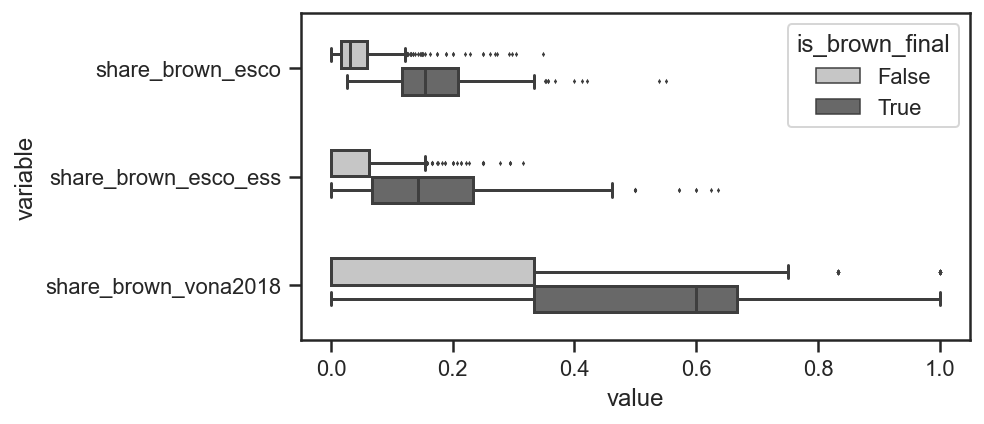

In [35]:
cols = [
    "is_brown_final",
    "share_brown_esco",
    "share_brown_esco_ess",
    "share_brown_vona2018",
]

df_long = brown_long_vs_short_list[cols].melt(id_vars="is_brown_final")

ax = sns.boxplot(
    data=df_long,
    y="variable",
    x="value",
    hue="is_brown_final",
    orient="h",
    width=0.5,
    fliersize=0.5,
    palette="Greys",
)

In [36]:
import pingouin as pg
from scipy.stats import ttest_ind

ttest_ind(
    brown_long_vs_short_list.loc[brown_long_vs_short_list["is_brown_final"] == True][
        "share_brown_esco"
    ],
    brown_long_vs_short_list.loc[brown_long_vs_short_list["is_brown_final"] == False][
        "share_brown_esco"
    ],
)

Ttest_indResult(statistic=26.98876400936186, pvalue=1.7603720923524165e-118)

#### Prepare lower/upper bound files for export

1) Brown file

In [37]:
cols2drop = [
    "gbn_classification_esco",
    "gbn_classification_esco_ess",
    "is_brown_eth",
    "classification_felix",
    "is_brown_felix2",
    "is_brown_jrc",
    "is_brown_consoli",
]
brown_long_vs_short_list_out = brown_long_vs_short_list.drop(columns=cols2drop)
brown_long_vs_short_list_out = brown_long_vs_short_list_out.rename(
    columns={"is_brown_final": "short_list_brown"}
)
brown_long_vs_short_list_out["long_list_brown"] = True
brown_long_vs_short_list_out

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.0, the latest is 0.5.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


,id,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,short_list_brown,long_list_brown
0,1318,http://data.europa.eu/esco/occupation/5e748def...,marine fitter,"Marine fitters work primarily in fabrication, ...",7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,0.153846,0.130435,0.222222,False,True
1,1324,http://data.europa.eu/esco/occupation/f49d893a...,forestry machinery technician,Forestry machinery technicians maintain and tr...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,0.107143,0.157895,0.222222,False,True
2,1316,http://data.europa.eu/esco/occupation/599c2ce9...,forge equipment technician,Forge equipment technicians maintain and repai...,7233,723,72,7,Agricultural and industrial machinery mechanic...,Machinery mechanics and repairers,"Metal, machinery and related trades workers",Craft and related trades workers,0.078947,0.142857,0.222222,False,True
3,1005,http://data.europa.eu/esco/occupation/8d3fd879...,precast moulder,Precast moulders handcast decorative and struc...,8114,811,81,8,"Cement, stone and other mineral products machi...",Mining and mineral processing plant operators,Stationary plant and machine operators,Plant and machine operators and assemblers,0.550000,0.600000,0.250000,True,True
4,947,http://data.europa.eu/esco/occupation/ee37a4a5...,tracer powder blender,Tracer powder blenders operate machines and eq...,8131,813,81,8,Chemical products plant and machine operators,Chemical and photographic products plant and m...,Stationary plant and machine operators,Plant and machine operators and assemblers,0.538462,0.571429,0.666667,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,1305,http://data.europa.eu/esco/occupation/ac160654...,woodturner,Woodturners use a lathe to remove superfluous ...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,0.071429,0.117647,1.000000,False,True
913,1302,http://data.europa.eu/esco/occupation/77a05858...,wooden furniture machine operator,Wooden furniture machine operators run machine...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,0.057143,0.000000,1.000000,False,True
914,1304,http://data.europa.eu/esco/occupation/a77bc925...,wood pallet maker,Wood pallet makers create wood pallets for use...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,0.052632,0.000000,1.000000,False,True
915,1303,http://data.europa.eu/esco/occupation/7e08d38d...,wood boring machine operator,Wood boring machine operators use milling mach...,7523,752,75,7,Woodworking-machine tool setters and operators,"Wood treaters, cabinet-makers and related trad...","Food processing, wood working, garment and oth...",Craft and related trades workers,0.048780,0.000000,1.000000,False,True


In [38]:
brown_long_vs_short_list_out.query("short_list_brown == True").groupby(
    "isco_label_4"
).mean()

,id,isco_level_4,isco_level_3,isco_level_2,isco_level_1,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,short_list_brown,long_list_brown
isco_label_4,,,,,,,,,,
Agricultural and industrial machinery mechanics and repairers,1321.000000,7233.0,723.0,72.0,7.0,0.066667,0.000000,0.222222,1.0,1.0
Cartographers and surveyors,505.000000,2165.0,216.0,21.0,2.0,0.173913,0.125000,0.000000,1.0,1.0
"Cement, stone and other mineral products machine operators",1005.500000,8114.0,811.0,81.0,8.0,0.241042,0.295316,0.250000,1.0,1.0
Chemical engineers,665.500000,2145.0,214.0,21.0,2.0,0.074421,0.115801,1.000000,1.0,1.0
Chemical processing plant controllers,1831.500000,3133.0,313.0,31.0,3.0,0.129157,0.150000,1.000000,1.0,1.0
Chemical products plant and machine operators,933.625000,8131.0,813.0,81.0,8.0,0.221108,0.280285,0.666667,1.0,1.0
Chemists,719.000000,2113.0,211.0,21.0,2.0,0.125000,0.181818,0.500000,1.0,1.0
Civil engineers,634.500000,2142.0,214.0,21.0,2.0,0.073109,0.090909,0.000000,1.0,1.0
Earthmoving and related plant operators,1137.333333,8342.0,834.0,83.0,8.0,0.109568,0.103807,0.400000,1.0,1.0


In [39]:
brown_long_vs_short_list_out.query("long_list_brown == True").groupby(
    "isco_label_4"
).mean()

,id,isco_level_4,isco_level_3,isco_level_2,isco_level_1,share_brown_esco,share_brown_esco_ess,share_brown_vona2018,short_list_brown,long_list_brown
isco_label_4,,,,,,,,,,
Agricultural and industrial machinery mechanics and repairers,1317.0,7233.0,723.0,72.0,7.0,0.047385,0.063000,0.222222,0.058824,1.0
Agricultural technicians,1846.5,3142.0,314.0,31.0,3.0,0.025794,0.025000,0.000000,0.000000,1.0
Air conditioning and refrigeration mechanics,1514.0,7127.0,712.0,71.0,7.0,0.032258,0.064516,0.000000,0.000000,1.0
Aircraft engine mechanics and repairers,1327.5,7232.0,723.0,72.0,7.0,0.026014,0.017241,0.000000,0.000000,1.0
Aircraft pilots and related associate professionals,1594.0,3153.0,315.0,31.0,3.0,0.026316,0.000000,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...
Welders and flamecutters,1399.5,7212.0,721.0,72.0,7.0,0.182078,0.162034,0.000000,0.000000,1.0
Well drillers and borers and related workers,1014.0,8113.0,811.0,81.0,8.0,0.139236,0.167069,1.000000,0.888889,1.0
Wood processing plant operators,1033.0,8172.0,817.0,81.0,8.0,0.052939,0.041617,1.000000,0.000000,1.0


2. Green file

In [40]:
cols2drop = [
    "gbn_classification_esco",
    "gbn_classification_esco_ess",
    "is_green_eth",
    "is_green_jrc",
    "is_green_consoli",
]
green_long_vs_short_list_out = green_long_vs_short_list.drop(columns=cols2drop)
green_long_vs_short_list_out = green_long_vs_short_list_out.rename(
    columns={"is_green_final": "short_list_green"}
)
green_long_vs_short_list_out["long_list_green"] = True
green_long_vs_short_list_out

,Unnamed: 0,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,comment_tobi,is_green_flo,short_list_green,comment_flo,is_green_tobi,long_list_green
0,63,http://data.europa.eu/esco/occupation/bac64fa2...,energy assessor,Energy assessors determine the energy performa...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.909091,0.916667,0.000000,0.000000,0.285714,NaN,NaN,True,NaN,True,True
1,130,http://data.europa.eu/esco/occupation/779d13be...,natural resources consultant,Natural resources consultant provide advice on...,2133,213,21,2,Environmental protection professionals,Life science professionals,Science and engineering professionals,Professionals,0.787879,1.000000,1.000000,0.000000,0.400000,NaN,NaN,True,NaN,True,True
2,204,http://data.europa.eu/esco/occupation/114e1eff...,energy conservation officer,Energy conservation officers promote the conse...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.750000,0.714286,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
3,210,http://data.europa.eu/esco/occupation/ab762f91...,energy analyst,Energy analysts evaluate the consumption of en...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.708333,0.681818,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
4,216,http://data.europa.eu/esco/occupation/fd4b90ed...,environmental expert,Environmental experts search for technological...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.705882,0.863636,1.000000,1.000000,0.111111,NaN,NaN,True,NaN,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,2982,http://data.europa.eu/esco/occupation/f272a521...,medical device engineer,Medical device engineers design and develop me...,2152,215,21,2,Electronics engineers,Electrotechnology engineers,Science and engineering professionals,Professionals,0.009709,0.000000,0.227273,0.217391,0.000000,NaN,NaN,False,NaN,NaN,True
593,2983,http://data.europa.eu/esco/occupation/fb18dfef...,service manager,Service managers are responsible for the super...,1349,134,13,1,Professional services managers not elsewhere c...,Professional services managers,Production and specialised services managers,Managers,0.009346,0.076923,0.000000,0.000000,0.100000,NaN,NaN,False,NaN,NaN,True
594,2985,http://data.europa.eu/esco/occupation/fb7e2f4f...,mechatronics engineer,Mechatronics engineers design and develop inte...,2144,214,21,2,Mechanical engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.009259,0.000000,0.285714,0.259259,0.000000,NaN,NaN,False,NaN,NaN,True
595,3006,http://data.europa.eu/esco/occupation/e1cf6897...,human resources manager,"Human resources managers plan, design and impl...",1212,121,12,1,Human resource managers,Business services and administration managers,Administrative and commercial managers,Managers,0.007194,0.000000,0.000000,0.000000,0.066667,NaN,NaN,False,NaN,NaN,True


In [41]:
green_long_vs_short_list_out.query("short_list_green == True")

,Unnamed: 0,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,comment_tobi,is_green_flo,short_list_green,comment_flo,is_green_tobi,long_list_green
0,63,http://data.europa.eu/esco/occupation/bac64fa2...,energy assessor,Energy assessors determine the energy performa...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.909091,0.916667,0.000000,0.000000,0.285714,NaN,NaN,True,NaN,True,True
1,130,http://data.europa.eu/esco/occupation/779d13be...,natural resources consultant,Natural resources consultant provide advice on...,2133,213,21,2,Environmental protection professionals,Life science professionals,Science and engineering professionals,Professionals,0.787879,1.000000,1.000000,0.000000,0.400000,NaN,NaN,True,NaN,True,True
2,204,http://data.europa.eu/esco/occupation/114e1eff...,energy conservation officer,Energy conservation officers promote the conse...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.750000,0.714286,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
3,210,http://data.europa.eu/esco/occupation/ab762f91...,energy analyst,Energy analysts evaluate the consumption of en...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.708333,0.681818,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
4,216,http://data.europa.eu/esco/occupation/fd4b90ed...,environmental expert,Environmental experts search for technological...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.705882,0.863636,1.000000,1.000000,0.111111,NaN,NaN,True,NaN,True,True
5,224,http://data.europa.eu/esco/occupation/b89ba3a8...,hazardous waste inspector,Hazardous waste inspectors inspect industrial ...,3257,325,32,3,Environmental and occupational health inspecto...,Other health associate professionals,Health associate professionals,Technicians and associate professionals,0.696970,0.642857,1.000000,1.000000,0.290000,NaN,NaN,True,NaN,True,True
6,225,http://data.europa.eu/esco/occupation/c0489e22...,recycling specialist,Recycling specialists research recycling polic...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.675676,0.739130,1.000000,1.000000,0.111111,NaN,NaN,True,NaN,True,True
7,283,http://data.europa.eu/esco/occupation/8d586ee9...,environmental geologist,Environmental geologists study how mineral ope...,2114,211,21,2,Geologists and geophysicists,Physical and earth science professionals,Science and engineering professionals,Professionals,0.647059,0.833333,0.483871,0.483871,0.166667,NaN,NaN,True,NaN,True,True
8,284,http://data.europa.eu/esco/occupation/b7f47c25...,environmental protection manager,Environmental protection managers provide advi...,1349,134,13,1,Professional services managers not elsewhere c...,Professional services managers,Production and specialised services managers,Managers,0.645833,0.520000,0.000000,0.000000,0.300000,NaN,NaN,True,NaN,True,True
9,285,http://data.europa.eu/esco/occupation/0ecedad1...,environmental education officer,Environmental education officers are responsib...,5113,511,51,5,Travel guides,"Travel attendants, conductors and guides",Personal service workers,Service and sales workers,0.640000,0.500000,0.000000,0.000000,0.083333,NaN,NaN,True,NaN,True,True


In [42]:
green_long_vs_short_list_out.query("long_list_green == True").groupby(
    "isco_label_4"
).mean()

,Unnamed: 0,isco_level_4,isco_level_3,isco_level_2,isco_level_1,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,is_green_flo,short_list_green,long_list_green
isco_label_4,,,,,,,,,,,,,
Agricultural and forestry production managers,563.000000,1311.0,131.0,13.0,1.0,0.390244,0.666667,0.000000,0.000000,0.090909,NaN,0.0,1.0
Agricultural technicians,741.000000,3142.0,314.0,31.0,3.0,0.180331,0.141912,0.115385,0.120000,0.000000,NaN,0.0,1.0
Air conditioning and refrigeration mechanics,932.000000,7127.0,712.0,71.0,7.0,0.096774,0.032258,0.269231,0.233333,0.060606,NaN,0.0,1.0
Air traffic controllers,2475.333333,3154.0,315.0,31.0,3.0,0.025394,0.033603,0.000000,0.000000,0.200000,NaN,0.0,1.0
Air traffic safety electronics technicians,1677.000000,3155.0,315.0,31.0,3.0,0.051282,0.066667,0.000000,0.000000,0.200000,NaN,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Veterinarians,857.333333,2250.0,225.0,22.0,2.0,0.145455,0.171212,0.000000,0.000000,0.066667,NaN,0.0,1.0
Veterinary technicians and assistants,1719.250000,3240.0,324.0,32.0,3.0,0.048003,0.078267,0.000000,0.000000,0.066667,NaN,0.0,1.0
Vocational education teachers,1701.000000,2320.0,232.0,23.0,2.0,0.050000,0.000000,0.000000,0.000000,0.200000,NaN,0.0,1.0


In [43]:
green_long_vs_short_list_out.query("short_list_green == True")

,Unnamed: 0,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_green_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,comment_tobi,is_green_flo,short_list_green,comment_flo,is_green_tobi,long_list_green
0,63,http://data.europa.eu/esco/occupation/bac64fa2...,energy assessor,Energy assessors determine the energy performa...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.909091,0.916667,0.000000,0.000000,0.285714,NaN,NaN,True,NaN,True,True
1,130,http://data.europa.eu/esco/occupation/779d13be...,natural resources consultant,Natural resources consultant provide advice on...,2133,213,21,2,Environmental protection professionals,Life science professionals,Science and engineering professionals,Professionals,0.787879,1.000000,1.000000,0.000000,0.400000,NaN,NaN,True,NaN,True,True
2,204,http://data.europa.eu/esco/occupation/114e1eff...,energy conservation officer,Energy conservation officers promote the conse...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.750000,0.714286,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
3,210,http://data.europa.eu/esco/occupation/ab762f91...,energy analyst,Energy analysts evaluate the consumption of en...,3112,311,31,3,Civil engineering technicians,Physical and engineering science technicians,Science and engineering associate professionals,Technicians and associate professionals,0.708333,0.681818,1.000000,1.000000,0.285714,NaN,NaN,True,NaN,True,True
4,216,http://data.europa.eu/esco/occupation/fd4b90ed...,environmental expert,Environmental experts search for technological...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.705882,0.863636,1.000000,1.000000,0.111111,NaN,NaN,True,NaN,True,True
5,224,http://data.europa.eu/esco/occupation/b89ba3a8...,hazardous waste inspector,Hazardous waste inspectors inspect industrial ...,3257,325,32,3,Environmental and occupational health inspecto...,Other health associate professionals,Health associate professionals,Technicians and associate professionals,0.696970,0.642857,1.000000,1.000000,0.290000,NaN,NaN,True,NaN,True,True
6,225,http://data.europa.eu/esco/occupation/c0489e22...,recycling specialist,Recycling specialists research recycling polic...,2143,214,21,2,Environmental engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.675676,0.739130,1.000000,1.000000,0.111111,NaN,NaN,True,NaN,True,True
7,283,http://data.europa.eu/esco/occupation/8d586ee9...,environmental geologist,Environmental geologists study how mineral ope...,2114,211,21,2,Geologists and geophysicists,Physical and earth science professionals,Science and engineering professionals,Professionals,0.647059,0.833333,0.483871,0.483871,0.166667,NaN,NaN,True,NaN,True,True
8,284,http://data.europa.eu/esco/occupation/b7f47c25...,environmental protection manager,Environmental protection managers provide advi...,1349,134,13,1,Professional services managers not elsewhere c...,Professional services managers,Production and specialised services managers,Managers,0.645833,0.520000,0.000000,0.000000,0.300000,NaN,NaN,True,NaN,True,True
9,285,http://data.europa.eu/esco/occupation/0ecedad1...,environmental education officer,Environmental education officers are responsib...,5113,511,51,5,Travel guides,"Travel attendants, conductors and guides",Personal service workers,Service and sales workers,0.640000,0.500000,0.000000,0.000000,0.083333,NaN,NaN,True,NaN,True,True


3. Join to occ_metadata file & create long and short list classifications for subsetting

In [44]:
omd = pd.read_pickle(
    r"T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\data\interim\esco\occ_metadata_en_esco_nan_values_filled.pkl"
)

omd_merged = pd.merge(
    omd,
    green_long_vs_short_list_out[
        ["preferredLabel", "short_list_green", "long_list_green"]
    ],
    how="left",
    on="preferredLabel",
)
omd_merged = pd.merge(
    omd_merged,
    brown_long_vs_short_list_out[
        ["preferredLabel", "short_list_brown", "long_list_brown"]
    ],
    how="left",
    on="preferredLabel",
)
omd_merged.query("short_list_green == True")

,conceptUri,preferredLabel,description,isco_level_4,isco_level_3,isco_level_2,isco_level_1,isco_label_4,isco_label_3,isco_label_2,isco_label_1,share_green_esco,share_brown_esco,share_neutral_esco,gbn_classification_esco,share_green_esco_ess,share_brown_esco_ess,share_neutral_esco_ess,gbn_classification_esco_ess,share_green_gtp,share_green_vona2018,share_green_jrc,share_brown_vona2018,share_green_vona2019,share_green_gilli2020,short_list_green,long_list_green,short_list_brown,long_list_brown
204,http://data.europa.eu/esco/occupation/114e1eff...,renewable energy consultant,Renewable energy consultants advise clients on...,2433,243,24,2,Technical and medical sales professionals (exc...,"Sales, marketing and public relations professi...",Business and administration professionals,Professionals,0.461538,0.000000,0.538462,neutral,0.611111,0.000000,0.388889,green,1.000000,1.000000,0.285714,0.000000,0.052632,0.069,True,True,NaN,NaN
216,http://data.europa.eu/esco/occupation/fd4b90ed...,solar energy sales consultant,Solar energy sales consultants provide advice ...,2433,243,24,2,Technical and medical sales professionals (exc...,"Sales, marketing and public relations professi...",Business and administration professionals,Professionals,0.292683,0.000000,0.707317,neutral,0.500000,0.000000,0.500000,green,1.000000,1.000000,0.000000,0.000000,0.052632,0.069,True,True,NaN,NaN
321,http://data.europa.eu/esco/occupation/bf802371...,radiation protection officer,Radiation protection officers are responsible ...,2263,226,22,2,Environmental and occupational health and hygi...,Other health professionals,Health professionals,Professionals,0.375000,0.000000,0.625000,neutral,0.272727,0.000000,0.727273,neutral,0.000000,0.000000,0.076923,0.000000,0.000000,0.000,True,True,NaN,NaN
553,http://data.europa.eu/esco/occupation/0e99c929...,renewable energy engineer,Renewable energy engineers research alternativ...,2149,214,21,2,Engineering professionals not elsewhere classi...,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.378049,0.000000,0.621951,neutral,0.424242,0.000000,0.575758,neutral,1.000000,0.952381,0.214286,0.000000,0.082044,0.198,True,True,NaN,NaN
559,http://data.europa.eu/esco/occupation/42dbb769...,solar energy engineer,Solar energy engineers design systems which ge...,2149,214,21,2,Engineering professionals not elsewhere classi...,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.269841,0.000000,0.730159,neutral,0.333333,0.000000,0.666667,neutral,1.000000,0.952381,0.214286,0.000000,0.082044,0.198,True,True,NaN,NaN
585,http://data.europa.eu/esco/occupation/f14194e2...,nuclear engineer,Nuclear engineers plan and design engineering ...,2149,214,21,2,Engineering professionals not elsewhere classi...,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.090909,0.000000,0.909091,neutral,0.064516,0.000000,0.935484,neutral,1.000000,0.952381,0.214286,0.000000,0.082044,0.198,True,True,NaN,NaN
630,http://data.europa.eu/esco/occupation/3f3748a7...,rail project engineer,"Rail project engineers maintain a safe, cost-e...",2142,214,21,2,Civil engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.083333,0.000000,0.916667,neutral,0.100000,0.000000,0.900000,neutral,0.470588,0.470588,0.111111,0.000000,0.000000,0.198,True,True,NaN,NaN
632,http://data.europa.eu/esco/occupation/9740933e...,wastewater engineer,Wastewater engineers design sewage systems and...,2142,214,21,2,Civil engineers,Engineering professionals (excluding electrote...,Science and engineering professionals,Professionals,0.333333,0.030303,0.636364,neutral,0.117647,0.058824,0.823529,neutral,0.470588,0.470588,0.083333,0.000000,0.000000,0.198,True,True,False,True
637,http://data.europa.eu/esco/occupation/e12f08fb...,hydropower engineer,"Hydropower engineers research, design and plan...",2142,21

In [45]:
omd.preferredLabel.unique()

array(['technical director', 'video and motion picture director',
       'performance lighting director', ..., 'pizzaiolo',
       'kitchen assistant', 'kitchen porter'], dtype=object)

#### Read ESCO - KldB crosswalk
final version

In [46]:
# read esco-dkz-kldb crosswalk
cw_kldb_merged_v2 = pd.read_pickle(
    os.path.join(
        useful_paths.data_processed, "crosswalks", "crosswalk_esco_kldb2010_final.pkl"
    )
)
cw_kldb_merged_v2

,Classification_1_URI,Classification_1_PrefLabel,Classification_2_ID_Raw,Classification_2_ID,Classification_2_PrefLabel,Mapping_relation,Editorial_note,kldb2010_code,kldb2010_name_de,kldb2010_name_en
0,http://data.europa.eu/esco/isco/C0110,Offiziere in regulären Streitkräften,B 01104-104,1104,Offizier im Sanitätsdienst,skos:narrowMatch,Alternativmapping über ISCO-2008,1104.0,Offiziere,Commissioned officers
1,http://data.europa.eu/esco/isco/C0110,Offiziere in regulären Streitkräften,B 01104-105,1104,Offizier im Geoinformationsdienst,skos:narrowMatch,Alternativmapping über ISCO-2008,1104.0,Offiziere,Commissioned officers
2,http://data.europa.eu/esco/isco/C0110,Offiziere in regulären Streitkräften,B 01104-106,1104,Offizier im Militärmusikdienst,skos:narrowMatch,Alternativmapping über ISCO-2008,1104.0,Offiziere,Commissioned officers
3,http://data.europa.eu/esco/isco/C0210,Unteroffiziere in regulären Streitkräften,B 01302-101,1302,Fachunteroffizier im allgemeinen Fachdienst,skos:narrowMatch,Alternativmapping über ISCO-2008,1302.0,Unteroffiziere ohne Portepee,Junior non-commissioned officers
4,http://data.europa.eu/esco/isco/C0210,Unteroffiziere in regulären Streitkräften,B 01203-100,1203,Feldwebel im Truppendienst,skos:narrowMatch,Alternativmapping über ISCO-2008,1203.0,Unteroffiziere mit Portepee,Senior non-commissioned officers and higher
...,...,...,...,...,...,...,...,...,...,...
8730,http://data.europa.eu/esco/occupation/e16e4cb0...,Waschsalongehilfe/Waschsalongehilfin,BE 9629,9629,"Hilfsarbeitskräfte, anderweitig nicht genannt",skos:broadMatch,Alternativmapping über ISCO-2008,NaN,NaN,NaN
8731,http://data.europa.eu/esco/occupation/9e4269d5...,Zentralbankgouverneur/Zentralbankgouverneurin,BE 1112,1112,Leitende Verwaltungsbedienstete,skos:broadMatch,Alternativmapping über ISCO-2008,NaN,NaN,NaN
8732,http://data.europa.eu/esco/occupation/6e1b1bd7...,Zulassungskoordinator/Zulassungskoordinatorin,BE 2359,2359,"Lehrkräfte, anderweitig nicht genannt",skos:broadMatch,Alternativmapping über ISCO-2008,NaN,NaN,NaN
8733,http://data.europa.eu/esco/occupation/39c89133...,Zulassungssachbearbeiter/Zulassungssachbearbei...,BE 3354,3354,"Fachkräfte bei staatlichen Pass-, Lizenz- und ...",skos:broadMatch,Alternativmapping über ISCO-2008,NaN,NaN,NaN


In [47]:
# read kldb names
kldb_names = pd.read_excel(
    r"T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\rcode\B_Metadaten\Kldb2010-Englisch.xls",
    sheet_name="OccupationMetadata",
    usecols=["kldb2010_code", "kldb2010_name_de", "kldb2010_name_en"],
)
kldb_names

,kldb2010_code,kldb2010_name_de,kldb2010_name_en
0,11101,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...
1,11102,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...
2,11103,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...
3,11104,Berufe in der Landwirtschaft (ohne Spezialisie...,Occupations in farming (without specialisation...
4,11113,Berufe in der Landtechnik - komplexe Spezialis...,Technical occupations in farming-complex tasks
...,...,...,...
1281,94794,Führungskräfte im Museum,Managers in museum
1282,1104,Offiziere,Commissioned officers
1283,1203,Unteroffiziere mit Portepee,Senior non-commissioned officers and higher
1284,1302,Unteroffiziere ohne Portepee,Junior non-commissioned officers


In [48]:
# drop select columns for KLDB version (gilli, esco neutral, vona 2019)
omd_merged = omd_merged.drop(
    columns=[
        "share_neutral_esco",
        "share_neutral_esco_ess",
        "share_green_vona2019",
        "share_green_gilli2020",
    ]
)

#### GBN classification based on short lists (ESCO-level)
- No need to do this for the long lists (there will be plenty of overlap, around n=263 occupations)

In [49]:
# find short list occupation classification
short_list_cols = omd_merged.columns[
    omd_merged.columns.str.contains("short_list")
].tolist()
short_list_data = omd_merged[short_list_cols].fillna(False)

# make sure there is no overlap between short lists
assert short_list_data.query(
    "short_list_green == True & short_list_brown == True"
).empty

# assign neutral occupations
short_list_data["short_list_neutral"] = False
short_list_data.loc[
    short_list_data.query(
        "short_list_green == False & short_list_brown == False"
    ).index,
    "short_list_neutral",
] = True

# create classification column
short_list_classification = (
    short_list_data.idxmax(axis=1).str.split(pat="_", expand=True).iloc[:, 2]
)
omd_merged["gbn_classification_short_list"] = short_list_classification

In [61]:
# save to data/processed
esco_level_gbn_classification = omd_merged[
    [
        "conceptUri",
        "preferredLabel",
        "description",
        "gbn_classification_esco",
        "gbn_classification_esco_ess",
        "gbn_classification_short_list",
    ]
]
esco_level_gbn_classification.to_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists.csv",
    ),
    encoding="utf-8",
)

#### Average at KldB level and write versions to excel

In [ ]:
# create excel sheet
fname_out = "occ_metadata_en_kldb2010_final_v4_short_list_updated.xlsx"
with pd.ExcelWriter(
    os.path.join(useful_paths.data_processed, "esco", fname_out)
) as writer:

    # 1) full version
    # --------------------------------------------
    cw_kldb_merged_with_omd = pd.merge(
        cw_kldb_merged_v2,
        omd_merged,
        left_on="Classification_1_URI",
        right_on="conceptUri",
        how="left",
    ).drop(
        columns=["Classification_2_ID"]
    )  # previous version: also drop column "DKZ-ID"

    kldb_level_shares = (
        cw_kldb_merged_with_omd.groupby("kldb2010_code").mean().reset_index()
    )
    kldb_level_shares = pd.merge(
        kldb_names, kldb_level_shares, on="kldb2010_code", how="left"
    )

    # write to excel
    kldb_level_shares.to_excel(writer, sheet_name="full_list")

    # 2) Upper/lower bound versions
    # --------------------------------------------
    subset_versions = [
        "short_list_green",
        "short_list_brown",
        "long_list_green",
        "long_list_brown",
    ]

    for subset_version in subset_versions:
        cw_kldb_merged_with_omd_subset = pd.merge(
            cw_kldb_merged_v2,
            omd_merged.query("{} == True".format(subset_version)),
            left_on="Classification_1_URI",
            right_on="conceptUri",
            how="left",
        ).drop(
            columns=["Classification_2_ID"]
        )  # previous version: also drop column "DKZ-ID"

        cw_kldb_merged_with_omd_subset = cw_kldb_merged_with_omd_subset.fillna(0)
        kldb_level_shares = (
            cw_kldb_merged_with_omd_subset.groupby("kldb2010_code").mean().reset_index()
        )
        kldb_level_shares = pd.merge(
            kldb_names, kldb_level_shares, on="kldb2010_code", how="left"
        )

        # write to excel
        kldb_level_shares.to_excel(writer, sheet_name=subset_version)

writer.save()

#### GBN classification based on short lists (KldB-level)

Number of G/B/N ESCO occupations per KldB code

In [ ]:
cat_per_kldb_code = (
    cw_kldb_merged_with_omd.groupby(["kldb2010_code", "gbn_classification_short_list"])[
        "gbn_classification_short_list"
    ]
    .count()
    .rename("n_esco")
    .reset_index()
)
cat_per_kldb_code["multiple_cats"] = cat_per_kldb_code.duplicated(
    subset=["kldb2010_code"], keep=False
)

kldb_gbn_classification = pd.merge(
    kldb_names, cat_per_kldb_code, on="kldb2010_code", how="left"
)

# save
fpath_out = os.path.join(
    useful_paths.data_processed,
    "esco",
    "occ_metadata_en_kldb2010_final_v4_short_list_gbn_clsf_updated.xlsx",
)
if not os.path.exists(fpath_out):
    print("saving")
    kldb_gbn_classification.to_excel(fpath_out)

In [ ]:
cw_kldb_merged_with_omd.groupby(
    ["kldb2010_code", "kldb2010_name_de", "gbn_classification_short_list"]
).max()

Number of ESCO occupations matched to each KldB occupation

In [ ]:
n_esco_matches_per_kldb = cw_kldb_merged_with_omd.groupby(
    ["kldb2010_code", "kldb2010_name_de"]
)["Classification_1_URI"].count()
n_esco_matches_per_kldb.sort_values(ascending=False).to_csv(
    os.path.join(
        useful_paths.data_processed,
        "crosswalks",
        "crosswalk_esco_kldb2010_match_summary_updated.csv",
    )
)

#### Calculating shares for occupation groups containing multiple categories
Logic:
- ESCO-level: binary
- KldB-level: shares if multiple categories mapped to single occupation

In [ ]:
# subset occs mapped to multiple categories
mult_cats = kldb_gbn_classification[kldb_gbn_classification.multiple_cats == True]

cnt = 0
data_store = []
for grp, grp_df in kldb_gbn_classification.groupby("kldb2010_code"):

    # pivot long to wide, simplify multi-indices
    grp_df_piv = grp_df.pivot(
        index=[
            "kldb2010_code",
            "kldb2010_name_de",
            "kldb2010_name_en",
            "multiple_cats",
        ],
        columns=["gbn_classification_short_list"],
        values=["n_esco"],
    )
    grp_df_piv.columns = grp_df_piv.columns.get_level_values(1)
    grp_df_piv = grp_df_piv.reset_index()
    # grp_df_piv.index = grp_df_piv.index.get_level_values(0)

    # create missing column
    cols_all = {"green", "brown", "neutral"}
    cols_exist = set(grp_df_piv.columns.tolist())
    col_missing = list(cols_all - cols_exist)
    grp_df_piv[col_missing] = 0

    # calc shares
    grp_df_piv["N"] = grp_df_piv[list(cols_all)].sum(axis=1)

    for col in list(cols_all):
        grp_df_piv["share_{}".format(col)] = grp_df_piv[col] / grp_df_piv["N"]

    # append
    data_store.append(grp_df_piv)

# concat to new df
df_out = pd.concat(data_store)

# assign category where data is available
df_out["category"] = df_out[list(cols_all)].idxmax(axis=1)
df_out = df_out.reset_index(drop=True)
df_out.loc[df_out["multiple_cats"].isna(), "category"] = None

# drop empty column
df_out = df_out.dropna(axis=1, how="all")

In [ ]:
# save
fpath_out = os.path.join(
    useful_paths.data_processed,
    "esco",
    "occ_metadata_en_kldb2010_final_v4_short_list_gbn_clsf_updated_reformatted.xlsx",
)
if not os.path.exists(fpath_out):
    print("saving")
    df_out.to_excel(fpath_out)